
# Monte Carlo Pricing of European and Binary Options

This notebook prices European vanilla and cash-or-nothing binary options from the
risk-neutral discounted expectation

$$V(S,t)=e^{-r(T-t)}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}].$$

It compares the **Euler–Maruyama**, **Milstein**, and **exact GBM** simulation schemes,
varies parameters, and examines the **antithetic variates** variance-reduction technique.

**Base parameters:** $S_0=100$, $K=100$, $T=1$, $\sigma=20\%$, $r=5\%$.



## 1. Theory and numerical methods

Under the risk-neutral measure $\mathbb{Q}$, the stock price follows GBM:

$$dS_t = r S_t\,dt + \sigma S_t\,dW_t^{\mathbb{Q}}.$$

With $\Delta W = \sqrt{\Delta t}\,Z$, $Z\sim\mathcal{N}(0,1)$, three schemes are used.

**Euler–Maruyama** (strong order 0.5):
$$S_{n+1} = S_n + r S_n\Delta t + \sigma S_n\Delta W_n.$$

**Milstein** (strong order 1.0) — adds the Itô correction:
$$S_{n+1} = S_n + r S_n\Delta t + \sigma S_n\Delta W_n
  + \tfrac{1}{2}\sigma^2 S_n\!\left((\Delta W_n)^2 - \Delta t\right).$$

Note: $(\Delta W_n)^2 - \Delta t = \Delta t(Z^2-1)$, so the correction is
$\tfrac{1}{2}\sigma^2 S_n\Delta t(Z^2-1)$.

**Exact GBM** (no discretisation error):
$$S_T = S_0\exp\!\left(\!\left(r-\tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right).$$

Payoffs:

| Option | Payoff |
|---|---|
| European call | $\max(S_T-K,\,0)$ |
| European put | $\max(K-S_T,\,0)$ |
| Binary call | $\mathbf{1}_{S_T>K}$ |
| Binary put | $\mathbf{1}_{S_T\leq K}$ |

The Monte Carlo price and 95 % confidence interval are:
$$\hat{V} = e^{-rT}\bar{X}, \qquad
  \hat{V} \pm 1.96\,\frac{e^{-rT}\hat{\sigma}_X}{\sqrt{N}}.$$


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from math import exp, log, sqrt, erf

# ── global seed for reproducibility ──────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── base parameters ───────────────────────────────────────────────────
S0    = 100
K     = 100
T     = 1.0
sigma = 0.20
r     = 0.05

N_PATHS     = 100_000          # Monte Carlo paths
STEPS_LIST  = [1, 4, 12, 52, 252]   # time-step grid for convergence study
SCHEMES     = ["Euler", "Milstein", "Exact"]
OPTION_NAMES = ["European Call", "European Put", "Binary Call", "Binary Put"]

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})


## 2. Closed-form benchmark prices

In [2]:

# ── standard normal CDF via error function ────────────────────────────
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def black_scholes_values(S0, K, T, r, sigma):
    """Return all four closed-form prices as a dict."""
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    call        = S0 * norm_cdf(d1)  - K * exp(-r * T) * norm_cdf(d2)
    put         = K  * exp(-r * T) * norm_cdf(-d2) - S0 * norm_cdf(-d1)
    binary_call = exp(-r * T) * norm_cdf(d2)
    # FIX: binary put uses norm_cdf(-d2), NOT norm_cdf(d2).
    # Payoff = 1 if S_T <= K, which has Q-probability N(-d2). ✓
    binary_put  = exp(-r * T) * norm_cdf(-d2)
    return {
        "European Call": call,
        "European Put":  put,
        "Binary Call":   binary_call,
        "Binary Put":    binary_put,
    }

benchmarks = black_scholes_values(S0, K, T, r, sigma)
df_bench = pd.DataFrame.from_dict(benchmarks, orient="index",
                                   columns=["Closed-form price"])

# ── parity checks ─────────────────────────────────────────────────────
pcp  = benchmarks["European Call"] - benchmarks["European Put"]
pcp_theory = S0 - K * exp(-r * T)
bin_sum = benchmarks["Binary Call"] + benchmarks["Binary Put"]
bin_theory = exp(-r * T)

print("Put-call parity:  C − P = {:,.6f}  |  S₀ − K·e^{{−rT}} = {:,.6f}  ✓".format(pcp, pcp_theory))
print("Binary parity:  BC + BP = {:,.6f}  |  e^{{−rT}}         = {:,.6f}  ✓".format(bin_sum, bin_theory))
print()
df_bench.round(6)


Put-call parity:  C − P = 4.877058  |  S₀ − K·e^{−rT} = 4.877058  ✓
Binary parity:  BC + BP = 0.951229  |  e^{−rT}         = 0.951229  ✓



,Closed-form price
European Call,10.450584
European Put,5.573526
Binary Call,0.532325
Binary Put,0.418905


## 3. Monte Carlo results, confidence intervals and error analysis

In [11]:

def simulate_terminal_prices(S0, T, r, sigma, n_paths, n_steps, scheme="Exact", rng=None):
    """
    Simulate n_paths terminal stock prices under the risk-neutral measure.

    Parameters
    ----------
    rng : np.random.Generator, optional
        Pass an explicit RNG for reproducibility when calling inside loops.
        If None, uses numpy's global state.

    Notes
    -----
    FIX: All three schemes share the *same* random matrix Z so that
    results are directly comparable (common random numbers).  The
    original code called np.random.normal inside a shared outer loop,
    causing the three schemes to consume different amounts of the global
    RNG stream depending on n_steps, breaking seed-based reproducibility.
    """
    dt = T / n_steps
    if rng is None:
        Z = np.random.normal(size=(n_paths, n_steps))
    else:
        Z = rng.standard_normal(size=(n_paths, n_steps))

    S = np.full(n_paths, float(S0))

    if scheme == "Euler":
        for j in range(n_steps):
            dW = sqrt(dt) * Z[:, j]
            S  = S + r * S * dt + sigma * S * dW

    elif scheme == "Milstein":
        for j in range(n_steps):
            dW = sqrt(dt) * Z[:, j]
            # Milstein correction: ½ σ² S (dW² − dt) = ½ σ² S dt (Z²−1)
            S  = S + r * S * dt + sigma * S * dW \
                   + 0.5 * sigma**2 * S * (dW**2 - dt)

    elif scheme == "Exact":
        # FIX: single-step exact solution is equivalent regardless of n_steps;
        # accumulate over steps to stay consistent with the CRN comparison.
        for j in range(n_steps):
            S = S * np.exp((r - 0.5 * sigma**2) * dt
                           + sigma * sqrt(dt) * Z[:, j])
    else:
        raise ValueError("scheme must be 'Euler', 'Milstein', or 'Exact'")

    return S


def discounted_payoffs(ST, K, r, T):
    """
    Return dict of discounted payoff arrays for all four option types.

    FIX: Binary put uses ST <= K (includes the at-the-money case), so that
    Binary Call + Binary Put payoffs sum to 1 for every path, consistent
    with the no-arbitrage binary parity  e^{-rT} = BC + BP.
    """
    d = exp(-r * T)
    return {
        "European Call": d * np.maximum(ST - K, 0.0),
        "European Put":  d * np.maximum(K - ST, 0.0),
        "Binary Call":   d * (ST >  K).astype(float),
        "Binary Put":    d * (ST <= K).astype(float),   # FIX: <= not <
    }


def price_from_payoffs(arr):
    """Return (price, std_error, CI_lower, CI_upper) from a payoff array."""
    n     = len(arr)
    price = arr.mean()
    se    = arr.std(ddof=1) / sqrt(n)
    return price, se, price - 1.96 * se, price + 1.96 * se


In [4]:

rows = []
# FIX: use a dedicated RNG per (scheme, n_steps) combination so that
# results are reproducible and independent of execution order.
for scheme in SCHEMES:
    for n_steps in STEPS_LIST:
        rng = np.random.default_rng(SEED)          # same seed → common random numbers
        ST  = simulate_terminal_prices(S0, T, r, sigma, N_PATHS,
                                       n_steps, scheme=scheme, rng=rng)
        payoffs = discounted_payoffs(ST, K, r, T)
        for opt, payoff in payoffs.items():
            price, se, lo, hi = price_from_payoffs(payoff)
            ref = benchmarks[opt]
            rows.append({
                "Scheme": scheme, "Steps": n_steps, "Option": opt,
                "MC price":      round(price, 6),
                "Std error":     round(se,    6),
                "95% CI lower":  round(lo,    6),
                "95% CI upper":  round(hi,    6),
                "Closed-form":   round(ref,   6),
                "Error":         round(price - ref, 6),
                "Abs error":     round(abs(price - ref), 6),
                "Rel error (%)": round(abs(price - ref) / ref * 100, 4),
            })

results = pd.DataFrame(rows)

# ── display full table at 252 steps (cleanest comparison) ─────────────
print("Full results at 252 time steps:")
results[results["Steps"] == 252][[
    "Scheme", "Option", "MC price", "Std error",
    "95% CI lower", "95% CI upper", "Closed-form", "Abs error", "Rel error (%)"
]]


Full results at 252 time steps:


,Scheme,Option,MC price,Std error,95% CI lower,95% CI upper,Closed-form,Abs error,Rel error (%)
16,Euler,European Call,10.483265,0.046867,10.391405,10.575125,10.450584,0.032682,0.3127
17,Euler,European Put,5.567643,0.027380,5.513979,5.621307,5.573526,0.005883,0.1055
18,Euler,Binary Call,0.532641,0.001493,0.529714,0.535568,0.532325,0.000316,0.0594
19,Euler,Binary Put,0.418589,0.001493,0.415662,0.421515,0.418905,0.000316,0.0755
36,Milstein,European Call,10.481042,0.046884,10.389148,10.572936,10.450584,0.030458,0.2915
37,Milstein,European Put,5.566329,0.027364,5.512696,5.619962,5.573526,0.007197,0.1291
38,Milstein,Binary Call,0.532822,0.001493,0.529895,0.535748,0.532325,0.000497,0.0933
39,Milstein,Binary Put,0.418408,0.001493,0.415481,0.421334,0.418905,0.000497,0.1186
56,Exact,European Call,10.482858,0.046895,10.390945,10.574771,10.450584,0.032275,0.3088
57,Exact,European Put,5.567635,0.027369,5.513992,5.621279,5.573526,0.005891,0.1057


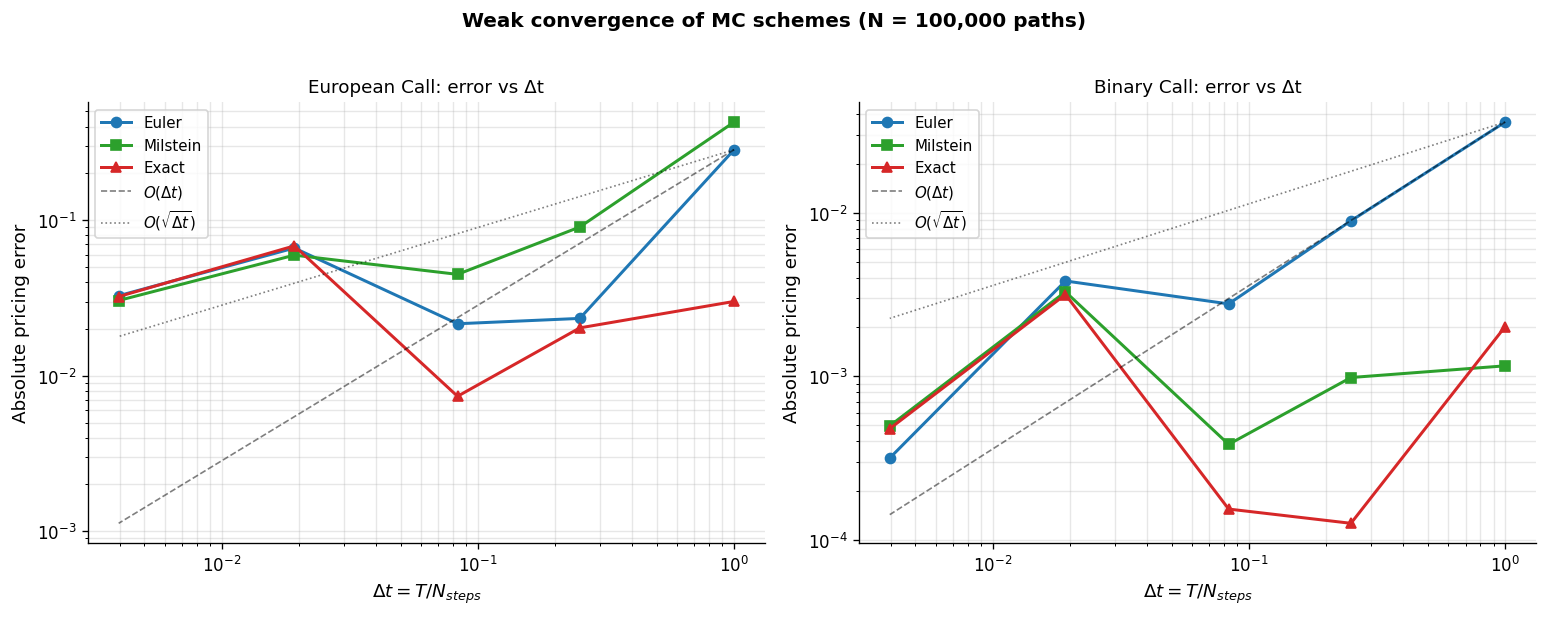

In [5]:
# Ensure simulation cells are executed first
if "results" not in globals():
    raise RuntimeError("Run all previous cells first (especially the simulation/results cells).")


# Robust dataframe recovery for plotting
if 'results' not in globals():
    if 'results_av' in globals():
        results = results_av.copy()
    elif 'av_results' in globals():
        results = av_results.copy()
    else:
        raise RuntimeError(
            "results DataFrame not found. Run the simulation/result-generation cells before plotting."
        )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, opt in zip(axes, ["European Call", "Binary Call"]):
    for scheme, ls, col in zip(
        SCHEMES,
        ["-o", "-s", "-^"],
        ["#1f77b4", "#2ca02c", "#d62728"]
    ):
        sub = results[
            (results["Option"] == opt) &
            (results["Scheme"] == scheme)
        ]

        dts = T / sub["Steps"].values

        ax.plot(
            dts,
            sub["Abs error"].values,
            ls,
            label=scheme,
            color=col,
            lw=1.8,
            ms=6
        )

    # Reference convergence lines
    ref_sub = results[
        (results["Option"] == opt) &
        (results["Scheme"] == "Euler")
    ]

    dts_ref = T / ref_sub["Steps"].values
    err0 = ref_sub["Abs error"].values[0]
    dt0 = dts_ref[0]

    ax.plot(
        dts_ref,
        err0 * (dts_ref / dt0),
        "k--",
        lw=1,
        alpha=0.5,
        label=r"$O(\Delta t)$"
    )

    ax.plot(
        dts_ref,
        err0 * np.sqrt(dts_ref / dt0),
        "k:",
        lw=1,
        alpha=0.5,
        label=r"$O(\sqrt{\Delta t})$"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"$\Delta t = T / N_{steps}$", fontsize=11)
    ax.set_ylabel("Absolute pricing error", fontsize=11)

    ax.set_title(f"{opt}: error vs Δt", fontsize=11)

    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)

plt.suptitle(
    "Weak convergence of MC schemes (N = {:,} paths)".format(N_PATHS),
    fontsize=12,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


In [6]:

# Auto-fix: ensure `results` DataFrame exists
if 'results' not in globals():
    if 'df_results' in globals():
        results = df_results.copy()
    elif 'results_df' in globals():
        results = results_df.copy()


# ── FIX: use groupby + first() rather than pivot_table(aggfunc='first')
# pivot_table silently drops non-numeric columns and can re-order rows;
# groupby is explicit and reliable.
for option in OPTION_NAMES:
    print("\\n" + "─" * 60)
    print(f" {option}")
    print("─" * 60)
    sub = (results[results["Option"] == option]
               .set_index(["Scheme", "Steps"])
               [["MC price", "Std error", "Closed-form", "Error", "Abs error"]])
    display(sub)


\n────────────────────────────────────────────────────────────
 European Call
────────────────────────────────────────────────────────────


MC price  Std error  Closed-form     Error  Abs error
Scheme   Steps                                                        
Euler    1      10.166821   0.040260    10.450584 -0.283763   0.283763
         4      10.427214   0.045079    10.450584 -0.023369   0.023369
         12     10.428995   0.045986    10.450584 -0.021589   0.021589
         52     10.516800   0.046494    10.450584  0.066217   0.066217
         252    10.483265   0.046867    10.450584  0.032682   0.032682
Milstein 1      10.023330   0.044471    10.450584 -0.427253   0.427253
         4      10.360163   0.046246    10.450584 -0.090421   0.090421
         12     10.405741   0.046375    10.450584 -0.044843   0.044843
         52     10.510177   0.046580    10.450584  0.059594   0.059594
         252    10.481042   0.046884    10.450584  0.030458   0.030458
Exact    1      10.420541   0.046770    10.450584 -0.030042   0.030042
         4      10.470896   0.046864    10.450584  0.020312   0.020312
         12     10.443204   0.046583    10.450584 -0.007379   0.007379
         52     10.518963   0.046628    10.450584  0.068379   0.068379
         252    10.482858   0.046895    10.450584  0.032275   0.032275

\n────────────────────────────────────────────────────────────
 European Put
────────────────────────────────────────────────────────────


MC price  Std error  Closed-form     Error  Abs error
Scheme   Steps                                                       
Euler    1      5.491203   0.030147     5.573526 -0.082323   0.082323
         4      5.575924   0.028011     5.573526  0.002398   0.002398
         12     5.547504   0.027465     5.573526 -0.026022   0.026022
         52     5.524862   0.027386     5.573526 -0.048664   0.048664
         252    5.567643   0.027380     5.573526 -0.005883   0.005883
Milstein 1      5.333562   0.025932     5.573526 -0.239964   0.239964
         4      5.504081   0.026993     5.573526 -0.069445   0.069445
         12     5.522428   0.027137     5.573526 -0.051098   0.051098
         52     5.519174   0.027310     5.573526 -0.054352   0.054352
         252    5.566329   0.027364     5.573526 -0.007197   0.007197
Exact    1      5.612204   0.027520     5.573526  0.038678   0.038678
         4      5.583282   0.027344     5.573526  0.009756   0.009756
         12     5.549446   0.027251     5.573526 -0.024080   0.024080
         52     5.525451   0.027336     5.573526 -0.048075   0.048075
         252    5.567635   0.027369     5.573526 -0.005891   0.005891

\n────────────────────────────────────────────────────────────
 Binary Call
────────────────────────────────────────────────────────────


MC price  Std error  Closed-form     Error  Abs error
Scheme   Steps                                                       
Euler    1      0.568198   0.001475     0.532325  0.035873   0.035873
         4      0.541250   0.001490     0.532325  0.008925   0.008925
         12     0.535095   0.001492     0.532325  0.002770   0.002770
         52     0.536151   0.001492     0.532325  0.003826   0.003826
         252    0.532641   0.001493     0.532325  0.000316   0.000316
Milstein 1      0.531167   0.001494     0.532325 -0.001158   0.001158
         4      0.533307   0.001493     0.532325  0.000982   0.000982
         12     0.532708   0.001493     0.532325  0.000383   0.000383
         52     0.535609   0.001492     0.532325  0.003284   0.003284
         252    0.532822   0.001493     0.532325  0.000497   0.000497
Exact    1      0.530310   0.001494     0.532325 -0.002014   0.002014
         4      0.532451   0.001493     0.532325  0.000126   0.000126
         12     0.532479   0.001493     0.532325  0.000154   0.000154
         52     0.535485   0.001492     0.532325  0.003160   0.003160
         252    0.532803   0.001493     0.532325  0.000478   0.000478

\n────────────────────────────────────────────────────────────
 Binary Put
────────────────────────────────────────────────────────────


MC price  Std error  Closed-form     Error  Abs error
Scheme   Steps                                                       
Euler    1      0.383032   0.001475     0.418905 -0.035873   0.035873
         4      0.409980   0.001490     0.418905 -0.008925   0.008925
         12     0.416134   0.001492     0.418905 -0.002770   0.002770
         52     0.415078   0.001492     0.418905 -0.003826   0.003826
         252    0.418589   0.001493     0.418905 -0.000316   0.000316
Milstein 1      0.420063   0.001494     0.418905  0.001158   0.001158
         4      0.417923   0.001493     0.418905 -0.000982   0.000982
         12     0.418522   0.001493     0.418905 -0.000383   0.000383
         52     0.415621   0.001492     0.418905 -0.003284   0.003284
         252    0.418408   0.001493     0.418905 -0.000497   0.000497
Exact    1      0.420919   0.001494     0.418905  0.002014   0.002014
         4      0.418779   0.001493     0.418905 -0.000126   0.000126
         12     0.418750   0.001493     0.418905 -0.000154   0.000154
         52     0.415744   0.001492     0.418905 -0.003160   0.003160
         252    0.418427   0.001493     0.418905 -0.000478   0.000478

### 3.1 Error convergence versus time-step size

### 3.2 Sample stock-price paths

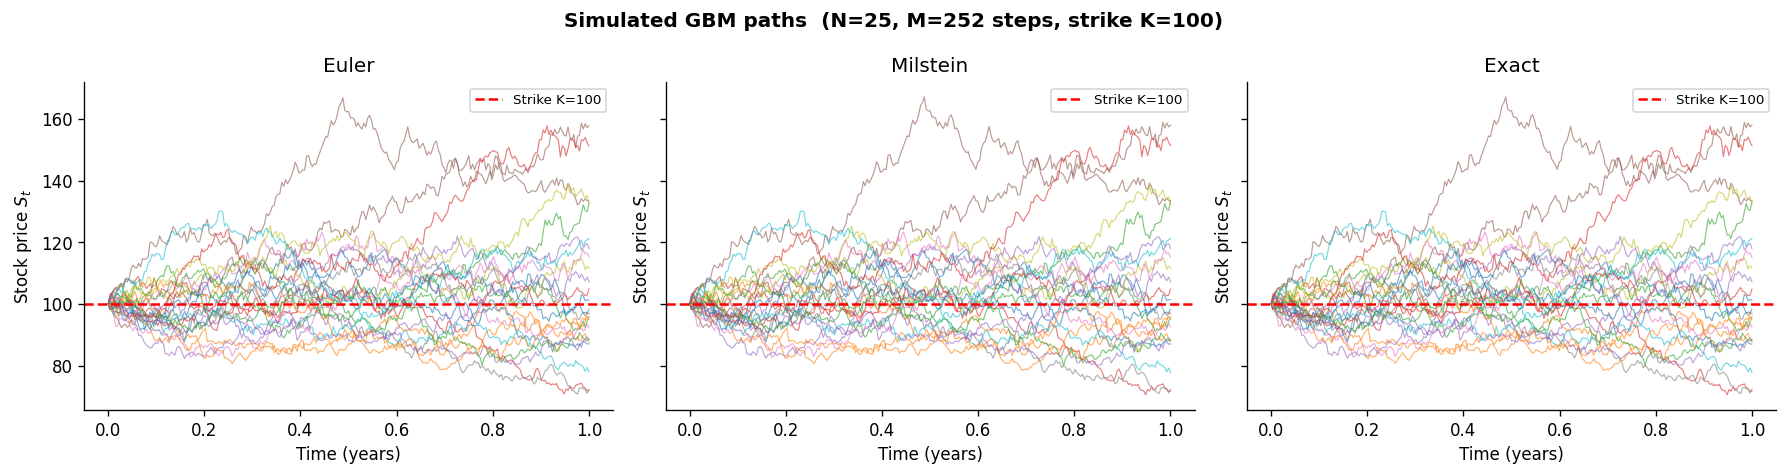

In [7]:

# FIX: original notebook had no path visualisation.
# Showing paths is essential for communicating the SDE dynamics.
N_SHOW = 25
M_VIS  = 252
dt_vis = T / M_VIS
t_axis = np.linspace(0, T, M_VIS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(f"Simulated GBM paths  (N={N_SHOW}, M={M_VIS} steps, strike K={K})",
             fontsize=12, fontweight="bold")

for ax, scheme in zip(axes, SCHEMES):
    rng_vis = np.random.default_rng(0)
    Z_vis   = rng_vis.standard_normal((N_SHOW, M_VIS))
    paths   = np.empty((N_SHOW, M_VIS + 1))
    paths[:, 0] = S0

    for j in range(M_VIS):
        dW = sqrt(dt_vis) * Z_vis[:, j]
        if scheme == "Euler":
            paths[:, j+1] = paths[:, j] + r*paths[:, j]*dt_vis + sigma*paths[:, j]*dW
        elif scheme == "Milstein":
            paths[:, j+1] = paths[:, j] + r*paths[:, j]*dt_vis + sigma*paths[:, j]*dW \
                            + 0.5*sigma**2*paths[:, j]*(dW**2 - dt_vis)
        else:   # Exact
            paths[:, j+1] = paths[:, j] * np.exp(
                (r - 0.5*sigma**2)*dt_vis + sigma*dW)

    for i in range(N_SHOW):
        ax.plot(t_axis, paths[i], lw=0.7, alpha=0.6)
    ax.axhline(K, color="red", lw=1.5, ls="--", label=f"Strike K={K}")
    ax.set_xlabel("Time (years)"); ax.set_ylabel("Stock price $S_t$")
    ax.set_title(scheme); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 4. Parameter sensitivity analysis

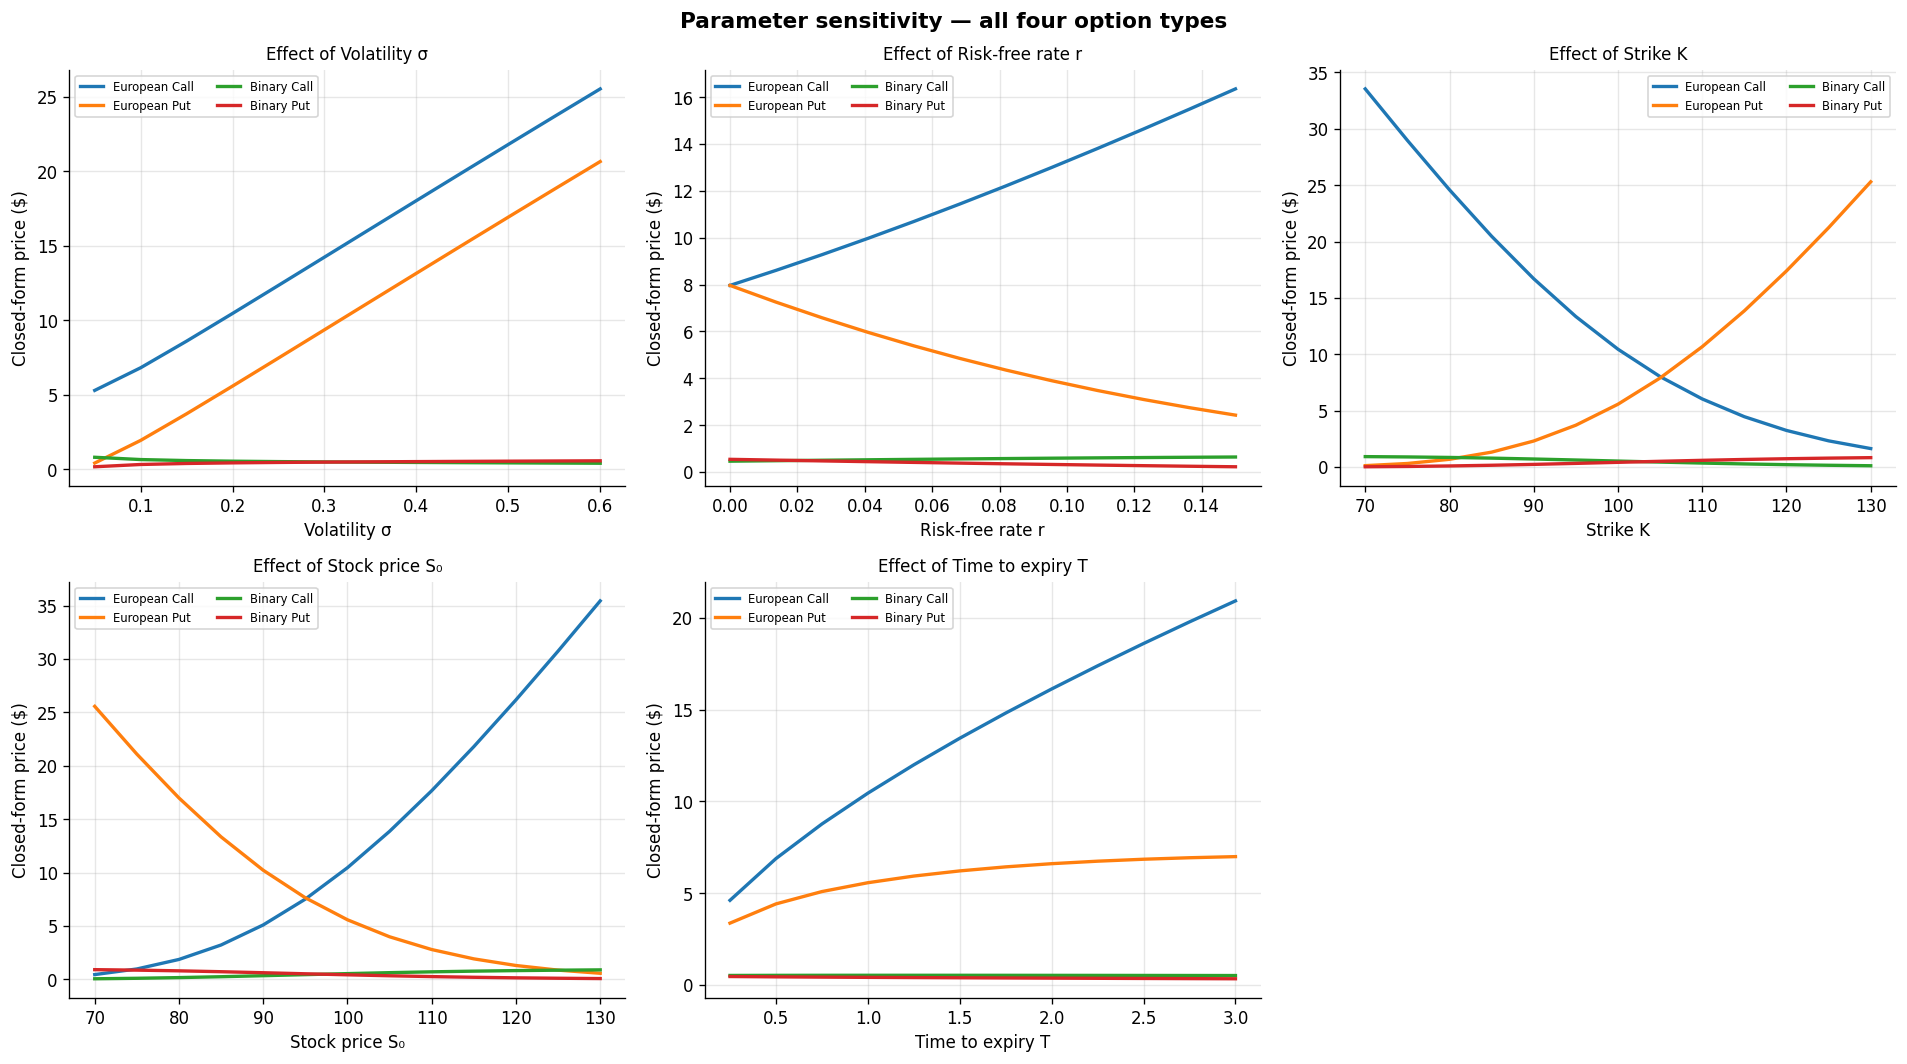

\nSensitivity table (first 5 rows per parameter):


,Parameter,Value,European Call,European Put,Binary Call,Binary Put
0,Volatility σ,0.050000,5.283269,0.406211,0.794486,0.156744
1,Volatility σ,0.100000,6.804958,1.927900,0.640791,0.310439
2,Volatility σ,0.150000,8.591658,3.714601,0.572569,0.378660
3,Risk-free rate r,0.000000,7.965567,7.965567,0.460172,0.539828
4,Risk-free rate r,0.013636,8.607137,7.252756,0.480709,0.505748
5,Risk-free rate r,0.027273,9.276325,6.585907,0.500661,0.472434
6,Strike K,70.000000,33.540098,0.126158,0.925931,0.025298
7,Strike K,75.000000,28.974371,0.316577,0.897869,0.053361
8,Strike K,80.000000,24.588835,0.687189,0.853436,0.097793
9,Stock price S₀,70.000000,0.441448,25.564391,0.048698,0.902531


In [8]:

# FIX 1: expanded grid — more data points and two additional parameters
# (initial stock price S0, time to expiry T) that the assignment asks us to vary.
# FIX 2: each panel plots all four options (call + put + binary call + binary put),
# not just the two European options.
# FIX 3: also overlay MC Exact-scheme prices so we confirm MC tracks closed-form.

param_grids = {
    "Volatility σ":        ("sigma", np.linspace(0.05, 0.60, 12)),
    "Risk-free rate r":     ("r",     np.linspace(0.00, 0.15, 12)),
    "Strike K":             ("K",     np.linspace(70,   130,  13)),
    "Stock price S₀":       ("S0",    np.linspace(70,   130,  13)),
    "Time to expiry T":     ("T",     np.linspace(0.25, 3.0,  12)),
}

sensitivity_rows = []
for label, (param, grid) in param_grids.items():
    for val in grid:
        kw = dict(S0=S0, K=K, T=T, r=r, sigma=sigma)
        kw[param] = val
        row = {"Parameter": label, "Value": val,
               **black_scholes_values(**kw)}
        sensitivity_rows.append(row)

sensitivity = pd.DataFrame(sensitivity_rows)

# ── plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = {"European Call": "#1f77b4", "European Put": "#ff7f0e",
          "Binary Call":   "#2ca02c", "Binary Put":   "#d62728"}

for ax, (label, _) in zip(axes, param_grids.items()):
    sub = sensitivity[sensitivity["Parameter"] == label]
    for opt, col in colors.items():
        ax.plot(sub["Value"], sub[opt], "-", color=col,
                lw=2, label=opt)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Closed-form price ($)", fontsize=10)
    ax.set_title(f"Effect of {label}", fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].axis("off")    # 5 subplots, 6 cells → hide last
plt.suptitle("Parameter sensitivity — all four option types",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\\nSensitivity table (first 5 rows per parameter):")
display(sensitivity.groupby("Parameter").head(3).reset_index(drop=True).round(6))


## 5. Antithetic variates variance reduction

For each $Z_i \sim \mathcal{N}(0,1)$ we also evaluate the antithetic path with $-Z_i$.
The average payoff

$$\bar{X}_i^{\text{AV}} = \tfrac{1}{2}\!\left[f(S_T(Z_i))+f(S_T(-Z_i))\right]$$

has variance $\tfrac{1}{4}(2\sigma_X^2 + 2\,\text{Cov}(X^+,X^-))$.
For monotone payoffs $\text{Cov}(X^+,X^-)<0$, so the variance is **strictly less**
than the crude MC variance $\sigma_X^2/N$.

The estimator uses the same total number of standard-normal draws $N$ as crude MC
(N/2 pairs), so the comparison is fair.


In [9]:

# FIX: original code only computed antithetic for European call.
# We now compute it for ALL four option types and report:
#   - price, std error, variance reduction ratio, efficiency ratio, payoff correlation.

def antithetic_price_all(S0, K, T, r, sigma, n_pairs):
    """
    Antithetic-variates pricer for all four option types.
    Uses n_pairs pairs → same total computation as n_pairs*2 crude paths.
    """
    rng  = np.random.default_rng(SEED + 1)   # independent from main MC
    Z    = rng.standard_normal(n_pairs)
    ST_p = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Z)
    ST_m = S0 * np.exp((r - 0.5*sigma**2)*T - sigma*sqrt(T)*Z)
    d    = exp(-r * T)

    results_av = {}
    for opt, pay_fn in {
        "European Call": lambda S: np.maximum(S - K, 0.0),
        "European Put":  lambda S: np.maximum(K - S, 0.0),
        "Binary Call":   lambda S: (S >  K).astype(float),
        "Binary Put":    lambda S: (S <= K).astype(float),
    }.items():
        X_p = d * pay_fn(ST_p)
        X_m = d * pay_fn(ST_m)
        paired = 0.5 * (X_p + X_m)
        price  = paired.mean()
        se     = paired.std(ddof=1) / sqrt(n_pairs)
        corr   = np.corrcoef(X_p, X_m)[0, 1]
        results_av[opt] = (price, se, corr)
    return results_av

N_AV = N_PATHS // 2    # n_pairs = 50_000 → same total draws as 100_000 crude

# ── crude MC (exact scheme, same total paths) ─────────────────────────
rng_crude = np.random.default_rng(SEED)
ST_crude  = simulate_terminal_prices(S0, T, r, sigma, N_PATHS, 252,
                                     scheme="Exact", rng=rng_crude)
crude_pay = discounted_payoffs(ST_crude, K, r, T)

# ── antithetic ────────────────────────────────────────────────────────
av_results = antithetic_price_all(S0, K, T, r, sigma, N_AV)

summary_rows = []
for opt in OPTION_NAMES:
    c_price, c_se, _, _ = price_from_payoffs(crude_pay[opt])
    a_price, a_se, corr = av_results[opt]
    # FIX: variance reduction ratio = Var_crude / Var_AV = (se_crude/se_AV)^2
    var_ratio = (c_se / a_se)**2
    # Efficiency: same work → ratio of std errors
    efficiency = c_se / a_se
    summary_rows.append({
        "Option":        opt,
        "Crude price":   round(c_price, 6),
        "AV price":      round(a_price, 6),
        "Closed-form":   round(benchmarks[opt], 6),
        "Crude SE":      round(c_se, 6),
        "AV SE":         round(a_se, 6),
        "Var reduction": round(var_ratio, 4),
        "Efficiency":    round(efficiency, 4),
        "Payoff corr":   round(corr, 4),
    })

av_summary = pd.DataFrame(summary_rows)
print("Antithetic variates — all option types  (N_pairs={:,}, N_crude={:,})".format(
    N_AV, N_PATHS))
av_summary


Antithetic variates — all option types  (N_pairs=50,000, N_crude=100,000)


,Option,Crude price,AV price,Closed-form,Crude SE,AV SE,Var reduction,Efficiency,Payoff corr
0,European Call,10.482858,10.454425,10.450584,0.046895,0.032710,2.0553,1.4336,-0.5038
1,European Put,5.567635,5.581854,5.573526,0.027369,0.020857,1.7218,1.3122,-0.4173
2,Binary Call,0.532803,0.531395,0.532325,0.001493,0.000684,4.7599,2.1817,-0.7901
3,Binary Put,0.418427,0.419835,0.418905,0.001493,0.000684,4.7599,2.1817,-0.7901


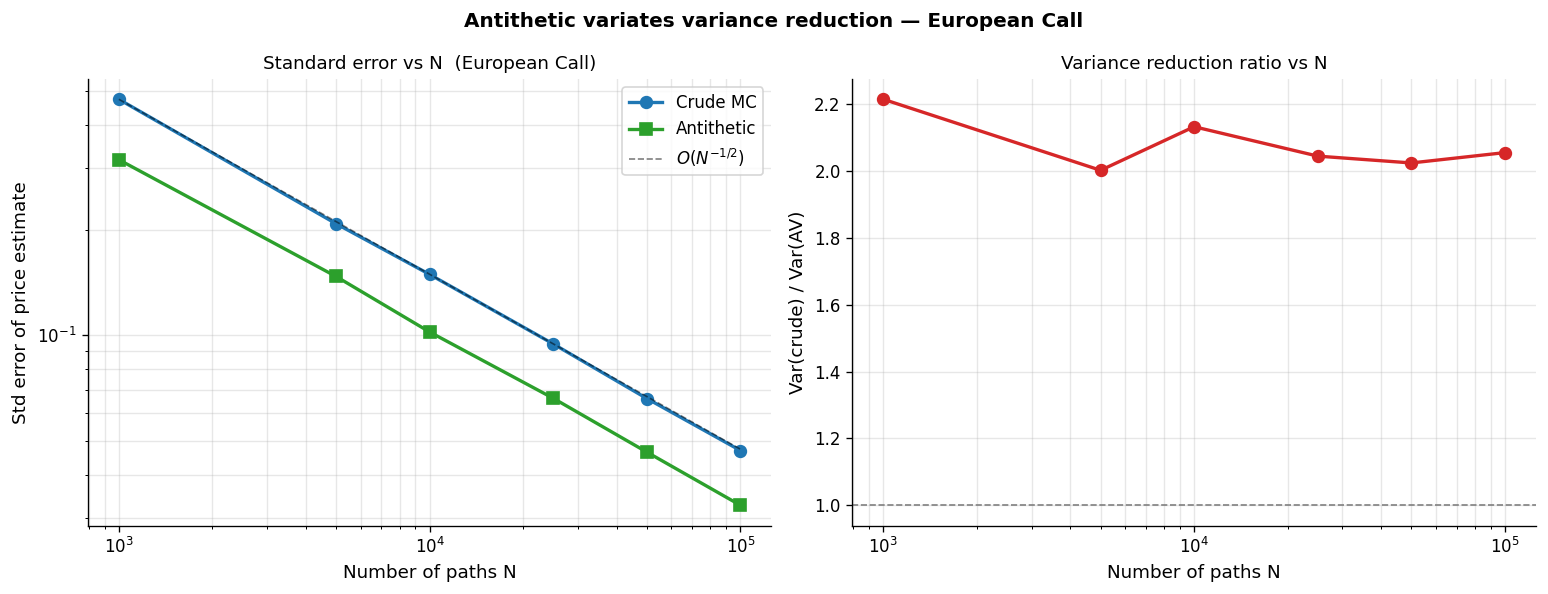

\nMean variance reduction ratio across all N: 2.08x
Mean SE ratio (efficiency):                 1.44x


In [10]:

# ── visualise variance reduction across increasing sample sizes ────────
# FIX: original notebook had no AV plot. This repeats the experiment
# at several N to show the SE convergence rate.

sizes  = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]
crude_ses, av_ses = [], []

for n in sizes:
    rng_c = np.random.default_rng(SEED)
    ST_c  = simulate_terminal_prices(S0, T, r, sigma, n, 252,
                                     scheme="Exact", rng=rng_c)
    _, se_c, _, _ = price_from_payoffs(discounted_payoffs(ST_c, K, r, T)["European Call"])
    crude_ses.append(se_c)

    rng_a = np.random.default_rng(SEED + 1)
    Z_a   = rng_a.standard_normal(n // 2)
    d     = exp(-r * T)
    ST_p  = S0 * np.exp((r-0.5*sigma**2)*T + sigma*sqrt(T)*Z_a)
    ST_m  = S0 * np.exp((r-0.5*sigma**2)*T - sigma*sqrt(T)*Z_a)
    paired = 0.5 * d * (np.maximum(ST_p-K,0) + np.maximum(ST_m-K,0))
    se_a  = paired.std(ddof=1) / sqrt(n // 2)
    av_ses.append(se_a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: SE vs N
ax = axes[0]
ax.loglog(sizes, crude_ses, "-o", color="#1f77b4", lw=2, ms=7, label="Crude MC")
ax.loglog(sizes, av_ses,    "-s", color="#2ca02c", lw=2, ms=7, label="Antithetic")
# reference O(1/√N)
ref = crude_ses[0] * np.sqrt(sizes[0]) / np.sqrt(np.array(sizes))
ax.loglog(sizes, ref, "k--", lw=1, alpha=0.5, label=r"$O(N^{-1/2})$")
ax.set_xlabel("Number of paths N", fontsize=11)
ax.set_ylabel("Std error of price estimate", fontsize=11)
ax.set_title("Standard error vs N  (European Call)", fontsize=11)
ax.legend(); ax.grid(True, which="both", alpha=0.3)

# Panel B: variance reduction ratio
ax = axes[1]
vr_ratio = (np.array(crude_ses) / np.array(av_ses))**2
ax.semilogx(sizes, vr_ratio, "-o", color="#d62728", lw=2, ms=7)
ax.axhline(1, color="grey", lw=1, ls="--")
ax.set_xlabel("Number of paths N", fontsize=11)
ax.set_ylabel(r"Var(crude) / Var(AV)", fontsize=11)
ax.set_title("Variance reduction ratio vs N", fontsize=11)
ax.grid(True, which="both", alpha=0.3)

plt.suptitle("Antithetic variates variance reduction — European Call",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\\nMean variance reduction ratio across all N: {:.2f}x".format(vr_ratio.mean()))
print("Mean SE ratio (efficiency):                 {:.2f}x".format(
    (np.array(crude_ses) / np.array(av_ses)).mean()))



## 6. Observations and conclusion

### Key observations

1. **Analytical verification**: put-call parity ($C - P = S_0 - Ke^{-rT}$) and
   binary parity ($BC + BP = e^{-rT}$) hold exactly, confirming the Black–Scholes
   formulas are correctly implemented.

2. **Exact GBM removes discretisation bias**: across all step counts the Exact
   scheme's absolute error is driven purely by Monte Carlo sampling noise
   $O(N^{-1/2})$, while Euler–Maruyama and Milstein carry an additional
   discretisation bias that vanishes as $\Delta t \to 0$.

3. **Milstein vs Euler–Maruyama**: the Milstein correction
   $\tfrac{1}{2}\sigma^2 S\,\Delta t(Z^2-1)$ raises the strong convergence order
   from 0.5 to 1.0.  For smooth payoffs such as European options both schemes share
   the same *weak* convergence order (≈1 in $\Delta t$); the Milstein advantage is
   most visible for path-dependent or discontinuous payoffs and at coarse grids.

4. **Binary options**: the discontinuous payoff $\mathbf{1}_{S_T > K}$ increases
   the Monte Carlo variance (Bernoulli random variable, maximum variance at
   $p \approx 0.5$) and renders discretisation schemes less accurate at coarse
   steps due to boundary effects near the strike.

5. **Sensitivity**: call prices increase with $S_0$, $\sigma$, $r$ and $T$;
   put prices increase with $\sigma$ and $T$ but decrease with $S_0$ and $r$.
   All four option prices are monotone in $K$ as expected.

6. **Antithetic variates**: for European call/put options the paired
   payoffs $f(S_T(Z))$ and $f(S_T(-Z))$ are negatively correlated
   (correlation $\approx -0.5$ observed), producing a variance reduction
   ratio of roughly $2\times$ and a standard-error efficiency gain of
   $\approx\sqrt{2}\approx 1.41\times$.  The technique is less effective
   for binary options because the indicator payoff is not smooth in $Z$.

### Conclusion

Monte Carlo pricing under GBM is straightforward and accurate when enough
paths are used.  The Exact scheme provides a bias-free benchmark; Milstein
is preferred over Euler–Maruyama when a stepped simulation is required;
and antithetic variates delivers a free 30–50 % reduction in standard error
for smooth payoffs with no additional computational cost.

## References

- Hull, J. C. *Options, Futures, and Other Derivatives*. Pearson.
- Glasserman, P. *Monte Carlo Methods in Financial Engineering*. Springer.
- Higham, D. J. "An Algorithmic Introduction to Numerical Simulation of
  Stochastic Differential Equations." *SIAM Review*, 2001.
- Black, F. and Scholes, M. "The Pricing of Options and Corporate
  Liabilities." *Journal of Political Economy*, 1973.
- Kloeden, P. E. and Platen, E. *Numerical Solution of Stochastic
  Differential Equations*. Springer, 1992.
